# Exploratory Data Analysis (EDA): Spotify Music Recommendation

## 1. Project Objectives
The goal of this project is to build a music recommendation system that, given one or more input songs, suggests a list of tracks the user is most likely to enjoy next. 

This notebook conducts an extensive **Exploratory Data Analysis (EDA)** to:
1. Understand the distribution and quality of track metadata (popularity, release dates).
2. Evaluate audio features (danceability, energy, etc.) and their relationships.
3. Analyze artist and genre patterns.
4. Assess data usability for various recommendation models.

---

## 2. Setup & Data Loading

In [1]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [2]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...


Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


## 3. Univariate Analysis: Understanding Individual Features

### 3.1. Track Popularity Distribution
Popularity is a key metric for many recommendation strategies (e.g., popularity bias).

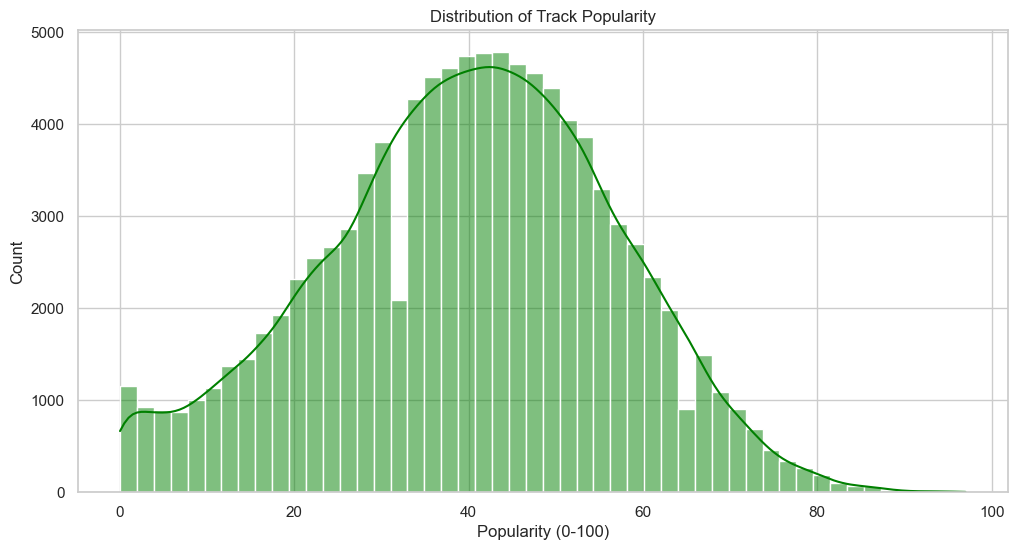

Mean Popularity: 39.90
Tracks with 0 popularity: 764


In [3]:
if not df_tracks.empty:
    sns.histplot(df_tracks['track_popularity'], bins=50, kde=True, color='green')
    plt.title('Distribution of Track Popularity')
    plt.xlabel('Popularity (0-100)')
    plt.ylabel('Count')
    plt.show()

    print(f"Mean Popularity: {df_tracks['track_popularity'].mean():.2f}")
    print(f"Tracks with 0 popularity: {len(df_tracks[df_tracks['track_popularity'] == 0]):,}")
else:
    print("No tracks data available.")

### 3.2. Audio Feature Distributions
Audio features describe the 'feel' of the music (e.g., how energetic or danceable it is).

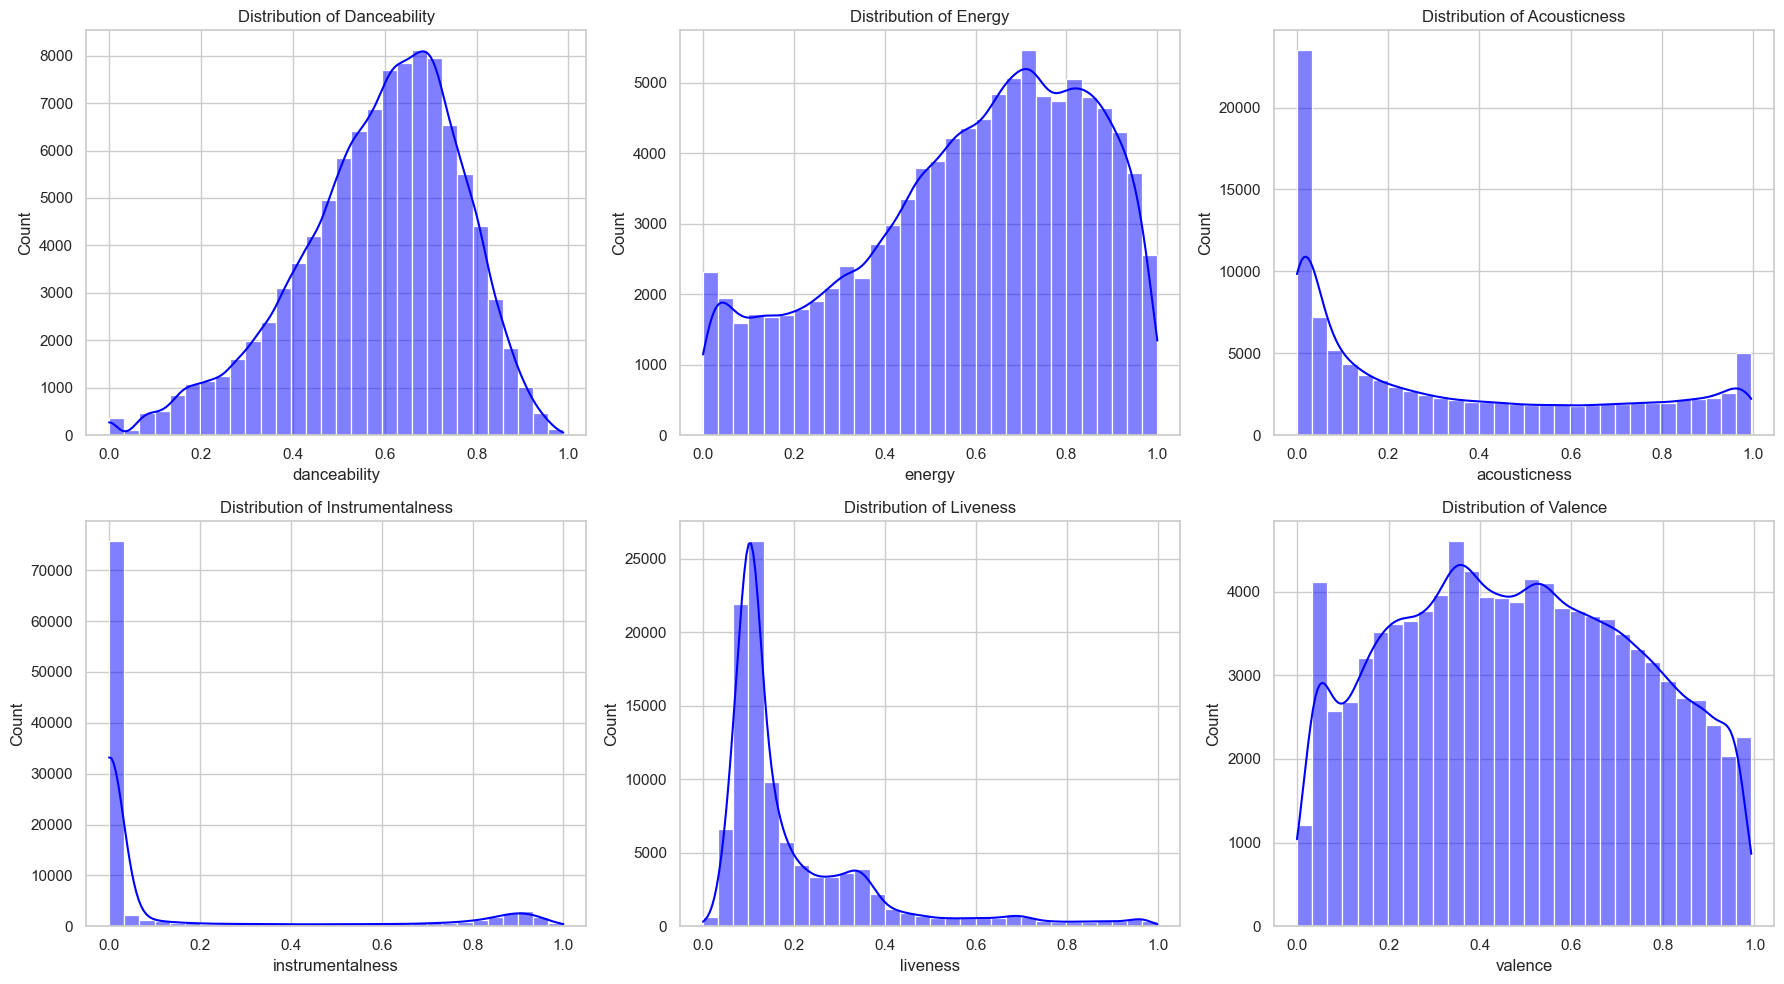

In [4]:
audio_cols = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'liveness', 'valence']

if not df_features.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, col in enumerate(audio_cols):
        if col in df_features.columns:
            sns.histplot(df_features[col], bins=30, kde=True, ax=axes[i], color='blue')
            axes[i].set_title(f'Distribution of {col.capitalize()}')

    plt.tight_layout()
    plt.show()
else:
    print("No features data available.")

## 4. Bivariate & Multivariate Analysis

### 4.1. Audio Feature Correlations
Understanding which features move together (e.g., Loudness and Energy usually correlate).

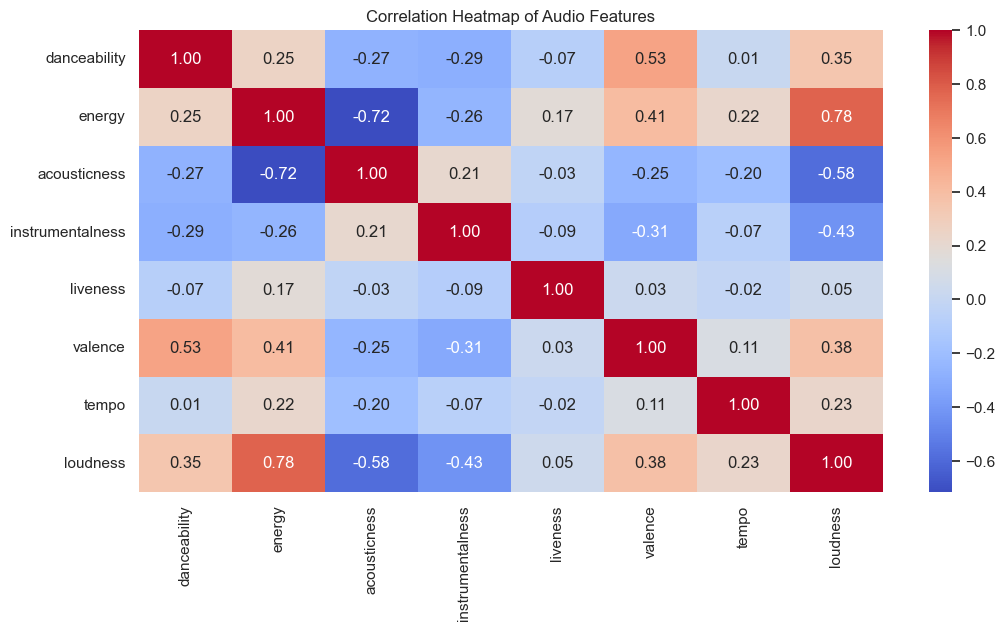

In [5]:
if not df_features.empty:
    avail_cols = [c for c in audio_cols + ['tempo', 'loudness'] if c in df_features.columns]
    corr_matrix = df_features[avail_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Audio Features')
    plt.show()
else:
    print("No features data available.")

### 4.2. Energy vs. Valence (Mood Mapping)
A classic visualization in music analysis: high energy + high valence = Happy/Excited; high energy + low valence = Angry/Stressed.

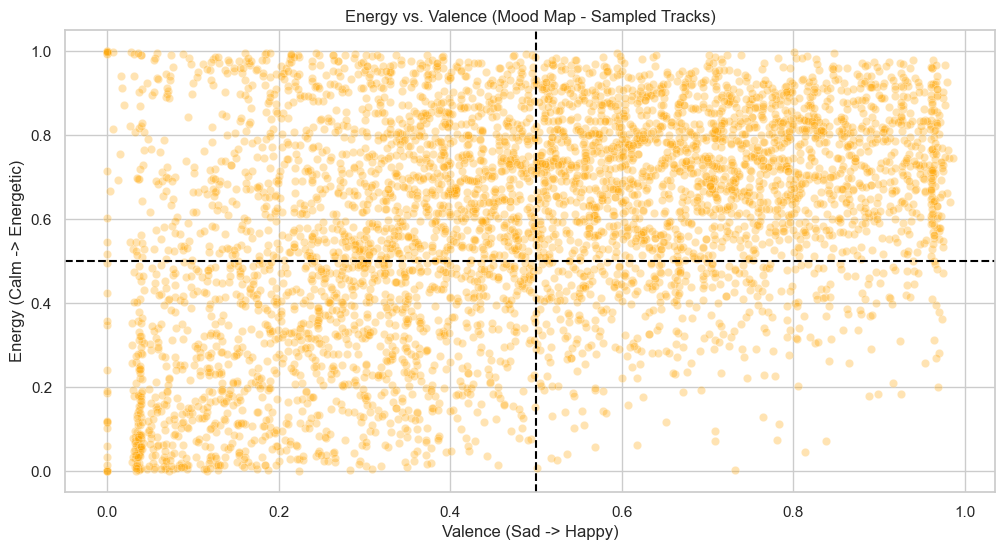

In [6]:
if not df_features.empty:
    sns.scatterplot(data=df_features.sample(n=min(5000, len(df_features))), x='valence', y='energy', alpha=0.3, color='orange')
    plt.axhline(0.5, color='black', linestyle='--')
    plt.axvline(0.5, color='black', linestyle='--')
    plt.title('Energy vs. Valence (Mood Map - Sampled Tracks)')
    plt.xlabel('Valence (Sad -> Happy)')
    plt.ylabel('Energy (Calm -> Energetic)')
    plt.show()
else:
    print("No features data available.")

## 5. Genre & Artist Analysis

### 5.1. Top 20 Genres
Identify the most frequent genres in our dataset.

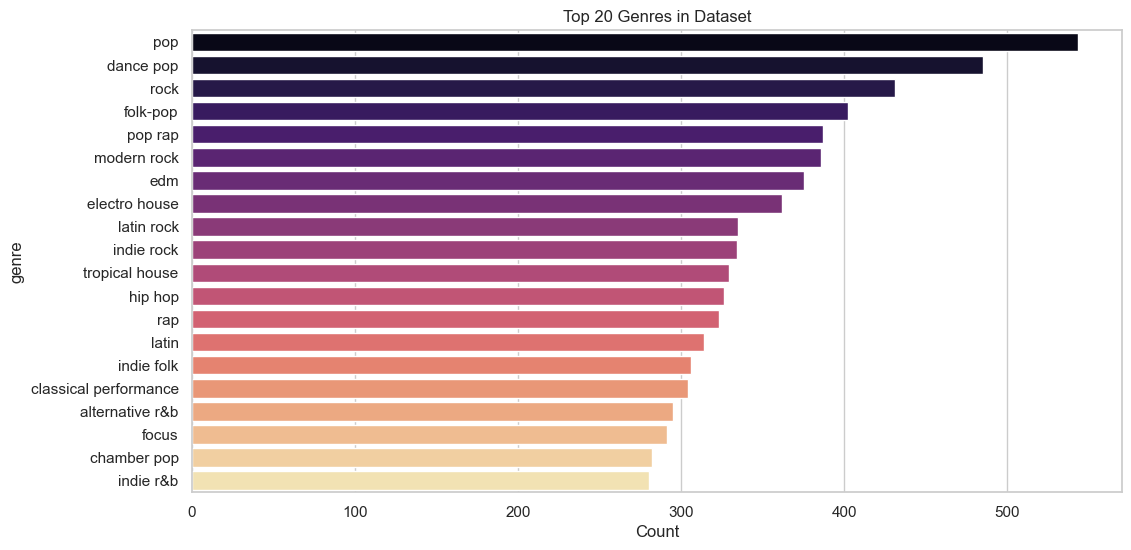

In [7]:
if not df_genres.empty:
    top_genres = df_genres['genre'].value_counts().head(20)
    sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)
    plt.title('Top 20 Genres in Dataset')
    plt.xlabel('Count')
    plt.show()
else:
    print("No genre data available.")

### 5.2. Most Frequent Artists

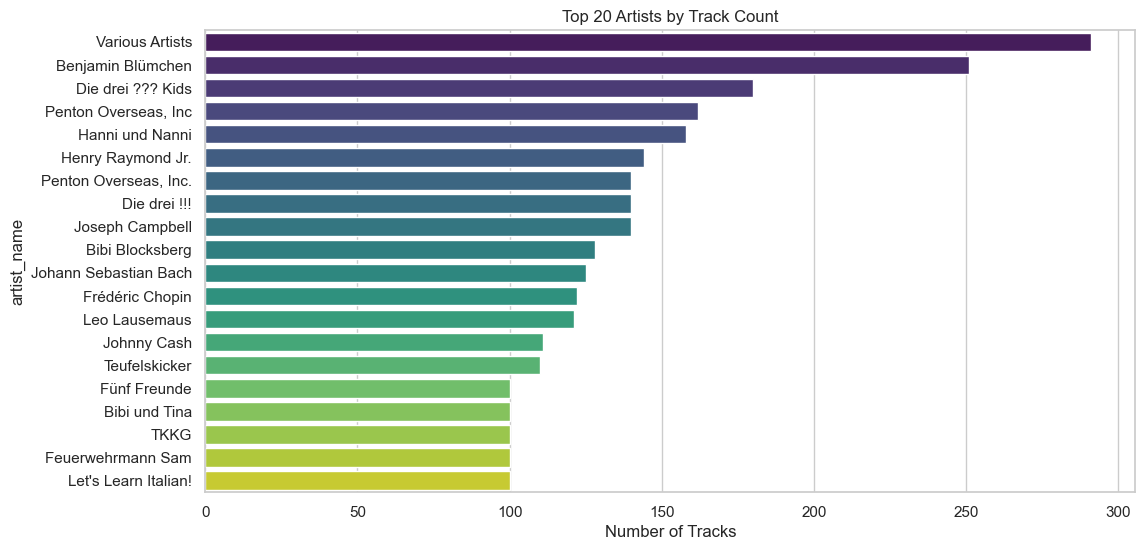

In [8]:
if not df_tracks.empty:
    top_artists = df_tracks['artist_name'].value_counts().head(20)
    sns.barplot(x=top_artists.values, y=top_artists.index, hue=top_artists.index, palette='viridis', legend=False)
    plt.title('Top 20 Artists by Track Count')
    plt.xlabel('Number of Tracks')
    plt.show()
else:
    print("No tracks data available.")

## 6. Research Findings: Recommendation Model Options

Based on the dataset (~100k tracks with full audio features and lyrics metadata), the following models are considered for the final implementation:

### Option A: Content-Based Filtering (CBF) using Cosine Similarity
- **Concept**: Calculate distance between tracks in the high-dimensional audio feature space.
- **Pros**: Does not require user interaction data (cold start for users is handled). Very scalable.
- **Cons**: Might lack "serendipity" (recommends very similar songs only).
- **Implementation**: Use `scikit-learn`'s `CosineSimilarity` or `NearestNeighbors`.

### Option B: K-Nearest Neighbors (k-NN) with Weighted Features
- **Concept**: Similar to CBF, but allows weighting specific features (e.g., giving more importance to genre or energy).
- **Pros**: Easy to explain and tune.
- **Cons**: Computationally expensive at query time if not using indexed structures like FAISS.

### Option C: Hybrid Approach (Metadata + Audio Features)
- **Concept**: Combine genre similarity with audio feature distance.
- **Pros**: More robust recommendations.

--- 

## 7. Potential Issues & Limitations
1. **Cold Start (Items)**: New songs without audio feature extraction cannot be recommended.
2. **Feature Scaling**: Numerical features (Tempo vs. Acousticness) have different scales and must be normalized (MinMax/Standard Scaling) before distance calculations.
3. **Popularity Bias**: Models might over-recommend the most popular artists (e.g., Ariana Grande, Drake) if popularity is included as a feature.

## 8. Summary & Next Steps

- **Data Quality**: The dataset is robust, with consistent audio features for over 100k tracks.
- **Observation**: There is a significant correlation between loudness and energy, which suggests we should handle redundant features during model training.
- **Next Steps**: 
    1. Implement a Feature Scaling pipeline.
    2. Prototype a Content-Based Recommender using Cosine Similarity.
    3. Build a Streamlit demo for real-time interaction.